In [2]:
from nse_scrap import * 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

# def Get_Stock_Data2(_tickers, _number_of_recent_days, _type="stock"):

#     df1 = Get_Stock_Data(_tickers[0],_number_of_recent_days)
#     # df1 = df1.set_index("date")
    
#     for tkr in _tickers[1:]:
#         t = Get_Stock_Data(tkr,_number_of_recent_days)
#         df1 = pd.concat([df1, t])
#     return df1


dfs = Get_Stock_Data3(['WSTCSTPAPR'], 250)

In [4]:
dfs

,date,symbol,high,low,open,close,volume,52WH,52WL
7,2023-01-11,WSTCSTPAPR,531.90,523.35,530.00,525.45,59232,663.95,217.0
8,2023-01-12,WSTCSTPAPR,541.95,526.00,528.00,539.20,97868,663.95,217.0
9,2023-01-13,WSTCSTPAPR,544.50,533.55,541.75,539.35,77999,663.95,217.0
10,2023-01-16,WSTCSTPAPR,543.35,533.55,540.00,534.75,61306,663.95,217.0
11,2023-01-17,WSTCSTPAPR,538.45,528.90,534.75,530.10,29878,663.95,217.0
...,...,...,...,...,...,...,...,...,...
252,2024-01-09,WSTCSTPAPR,713.65,699.00,709.90,705.30,152901,780.00,465.3
253,2024-01-10,WSTCSTPAPR,707.35,695.00,705.25,700.35,130050,780.00,465.3
254,2024-01-11,WSTCSTPAPR,708.55,697.35,703.15,706.05,109524,780.00,465.3
255,2024-01-12,WSTCSTPAPR,714.00,700.00,706.45,701.65,105240,780.00,465.3


In [5]:
# s = Get_Stock_Data('WSTCSTPAPR',300)
# p = dfs.pivot_table(index=["date"], columns=["symbol"], values =["close"]) 


In [6]:
# p.close

In [7]:
# p.close.INFY

In [8]:
s = dfs[ dfs["symbol"]=="WSTCSTPAPR"]
type(s)
# s.index=s.date
# s.head()

pandas.core.frame.DataFrame

In [9]:
s

,date,symbol,high,low,open,close,volume,52WH,52WL
7,2023-01-11,WSTCSTPAPR,531.90,523.35,530.00,525.45,59232,663.95,217.0
8,2023-01-12,WSTCSTPAPR,541.95,526.00,528.00,539.20,97868,663.95,217.0
9,2023-01-13,WSTCSTPAPR,544.50,533.55,541.75,539.35,77999,663.95,217.0
10,2023-01-16,WSTCSTPAPR,543.35,533.55,540.00,534.75,61306,663.95,217.0
11,2023-01-17,WSTCSTPAPR,538.45,528.90,534.75,530.10,29878,663.95,217.0
...,...,...,...,...,...,...,...,...,...
252,2024-01-09,WSTCSTPAPR,713.65,699.00,709.90,705.30,152901,780.00,465.3
253,2024-01-10,WSTCSTPAPR,707.35,695.00,705.25,700.35,130050,780.00,465.3
254,2024-01-11,WSTCSTPAPR,708.55,697.35,703.15,706.05,109524,780.00,465.3
255,2024-01-12,WSTCSTPAPR,714.00,700.00,706.45,701.65,105240,780.00,465.3


In [10]:
s["SMA5"] = s[["close"]].rolling(window=5).agg({"close":"mean"})
s["SMA15"]=s[["close"]].rolling(window=15).agg({"close":"mean"})
s["SMA50"]=s[["close"]].rolling(window=50).agg({"close":"mean"})


# s["52WH"]=s[["close"]].rolling(window=210).agg({"close":"max"})
# s["52WL"]=s[["close"]].rolling(window=210).agg({"close":"min"})
s["52WH_P"] = (s["52WH"] - s["close"])/s["52WH"] * 100
s["52WL_P"] = (s["close"] - s["52WL"])/s["52WL"] * 100
s["52WHLP"] = (s["close"] - s["52WL"])/(s["52WH"] - s["52WL"] ) * 100

# agg({"close":"avg"})
# r.sum()

In [11]:
s[["close", "52WL", "52WH"]]

,close,52WL,52WH
7,525.45,217.0,663.95
8,539.20,217.0,663.95
9,539.35,217.0,663.95
10,534.75,217.0,663.95
11,530.10,217.0,663.95
...,...,...,...
252,705.30,465.3,780.00
253,700.35,465.3,780.00
254,706.05,465.3,780.00
255,701.65,465.3,780.00


In [12]:
s["SMA5_2_50"] = s["SMA5"]- s["SMA50"]
s["SMA15_2_50"] = s["SMA15"]- s["SMA50"]

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

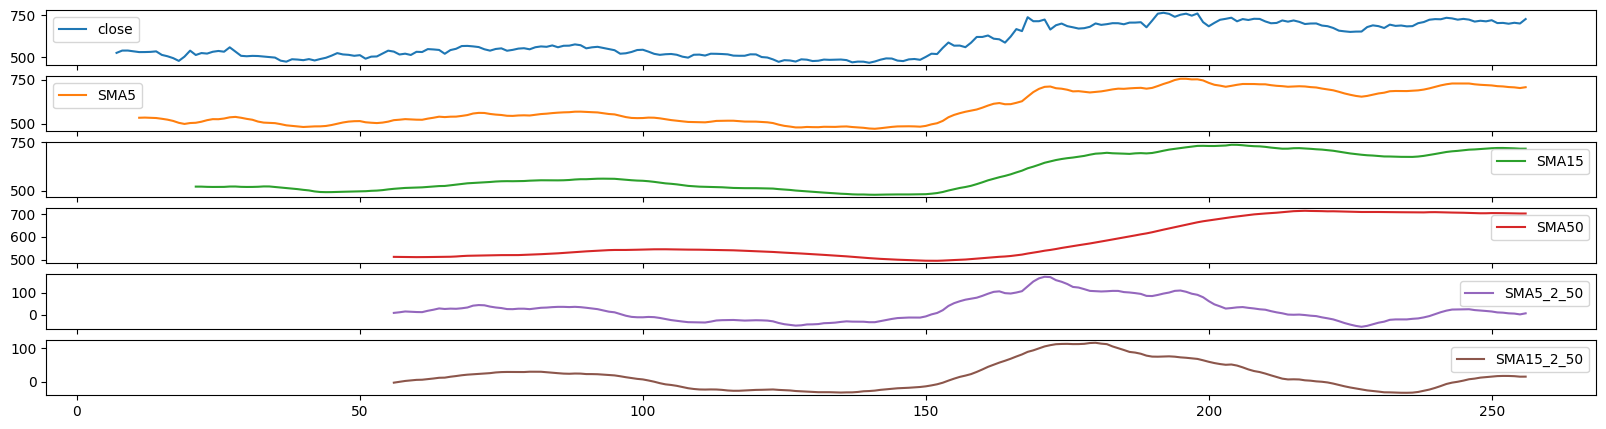

In [13]:
s[["close","SMA5","SMA15","SMA50","SMA5_2_50","SMA15_2_50"]].plot(subplots=True, figsize=(20,5))

In [14]:
# s["SIG"] = s["SMA5_2_50"].diff()[ (d> 0) & (d< 2) ]
s["SMA5_2_50_1"] = s["SMA5_2_50"].shift(1)
s["SIG"]=0
s.loc[ ((s["SMA5_2_50_1"] < 0 ) & (s["SMA5_2_50"] > 0 )), "SIG"] = 1 
s.loc[ ((s["SMA5_2_50_1"] > 0 ) & (s["SMA5_2_50"] < 0 )), "SIG"] = -1 

# s.loc[ s["SMA5_2_50_1"] <= s["SMA5_2_50"], "SIG"] = 0 


<Axes: >

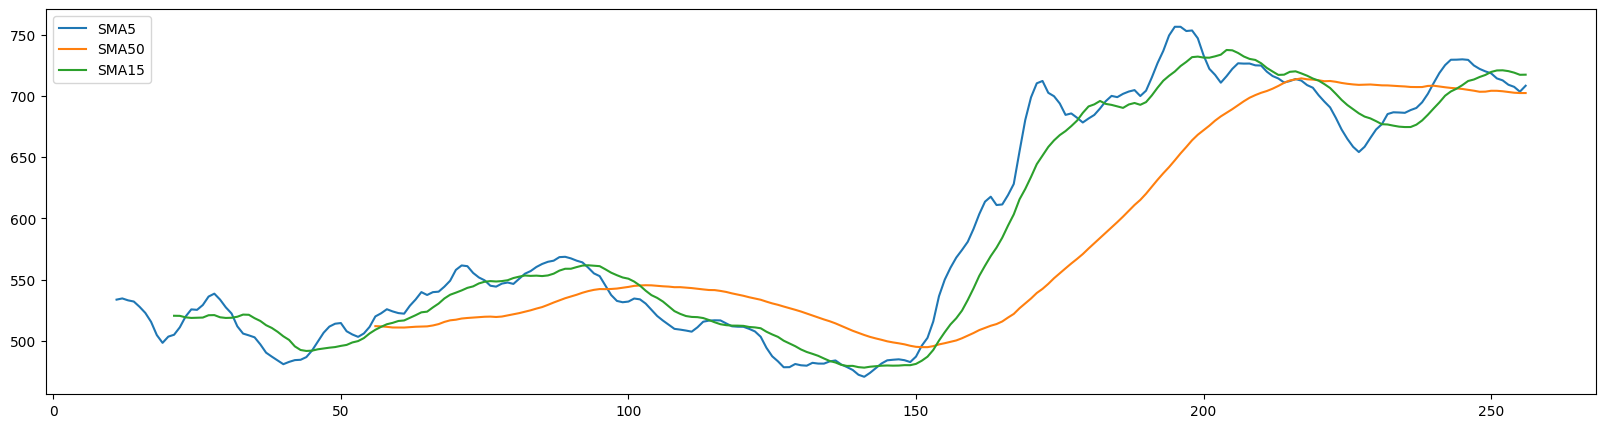

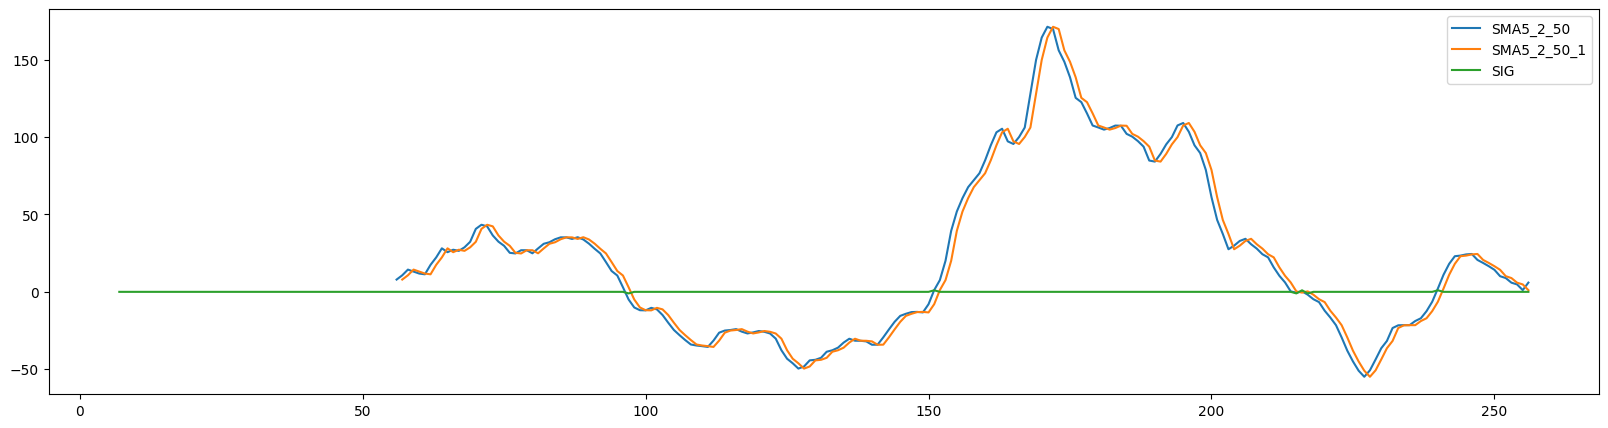

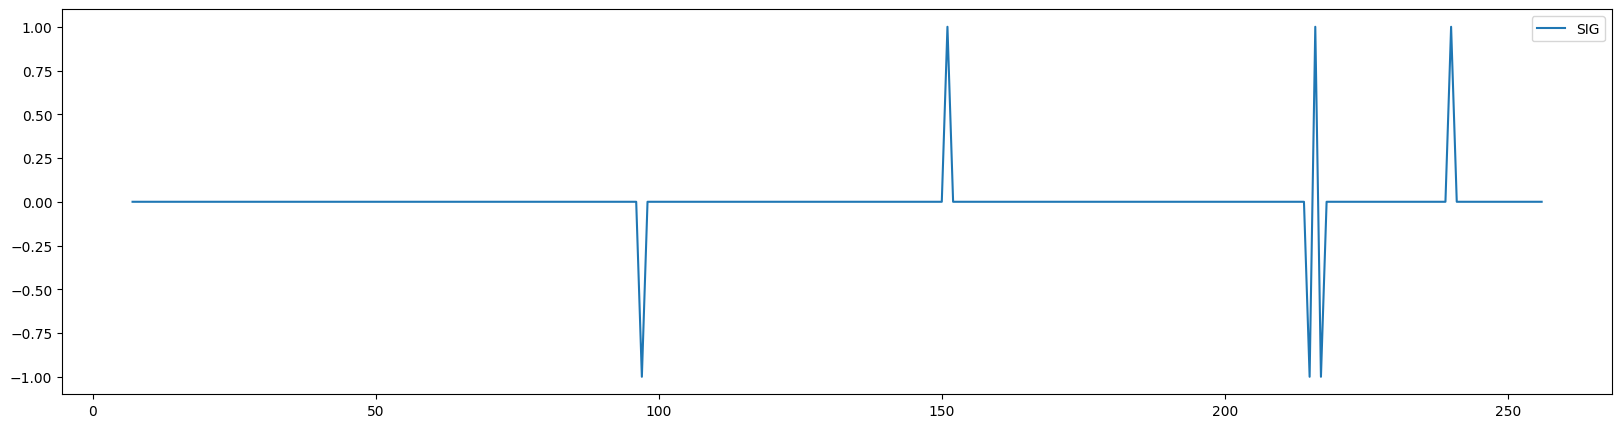

In [15]:
s[["SMA5","SMA50","SMA15" ]].plot(subplots=False, figsize=(20,5))
s[["SMA5_2_50","SMA5_2_50_1","SIG"]].plot(subplots=False, figsize=(20,5))
s[["SIG"]].plot(subplots=False, figsize=(20,5))


In [16]:

s.tail()

,date,symbol,high,low,open,close,volume,52WH,52WL,SMA5,SMA15,SMA50,52WH_P,52WL_P,52WHLP,SMA5_2_50,SMA15_2_50,SMA5_2_50_1,SIG
252,2024-01-09,WSTCSTPAPR,713.65,699.00,709.90,705.30,152901,780.0,465.3,712.76,720.963333,703.860,9.576923,51.579626,76.263108,8.900,17.103333,10.105,0
253,2024-01-10,WSTCSTPAPR,707.35,695.00,705.25,700.35,130050,780.0,465.3,709.19,720.290000,703.272,10.211538,50.515796,74.690181,5.918,17.018000,8.900,0
254,2024-01-11,WSTCSTPAPR,708.55,697.35,703.15,706.05,109524,780.0,465.3,707.46,719.063333,702.664,9.480769,51.740812,76.501430,4.796,16.399333,5.918,0
255,2024-01-12,WSTCSTPAPR,714.00,700.00,706.45,701.65,105240,780.0,465.3,703.51,717.303333,702.399,10.044872,50.795186,75.103273,1.111,14.904333,4.796,0
256,2024-01-15,WSTCSTPAPR,736.40,696.15,705.95,728.50,632218,780.0,465.3,708.37,717.393333,702.404,6.602564,56.565657,83.635208,5.966,14.989333,1.111,0


In [17]:
# s.apply(lambda x: print("Y") if ( s.SMA5_2_50_1 > s.SMA5_2_50 ) else print(""))
# s["SIG"] = 1 if (s.SMA5_2_50_1 > s.SMA5_2_50) 0 else 



In [18]:
s[ (s["SIG"]<0) | (s["SIG"]>0) ]

,date,symbol,high,low,open,close,volume,52WH,52WL,SMA5,SMA15,SMA50,52WH_P,52WL_P,52WHLP,SMA5_2_50,SMA15_2_50,SMA5_2_50_1,SIG
97,2023-05-26,WSTCSTPAPR,525.50,518.55,525.35,523.00,100802,663.95,285.95,537.52,555.760000,542.468,21.229008,82.899108,62.711640,-4.948,13.292000,2.950,-1
151,2023-08-11,WSTCSTPAPR,526.50,505.35,509.00,520.50,1303086,663.95,461.00,496.15,483.883333,495.004,21.605543,12.906725,29.317566,1.146,-11.120667,-7.979,1
215,2023-11-15,WSTCSTPAPR,729.85,708.10,721.95,719.90,201195,780.00,461.00,712.17,719.720000,712.663,7.705128,56.160521,81.159875,-0.493,7.057000,0.280,-1
216,2023-11-16,WSTCSTPAPR,738.00,708.80,724.85,711.55,251436,780.00,461.00,713.84,720.123333,713.532,8.775641,54.349241,78.542320,0.308,6.591333,-0.493,1
217,2023-11-17,WSTCSTPAPR,717.95,696.00,717.60,698.65,128909,780.00,461.00,712.56,718.430000,714.385,10.429487,51.550976,74.498433,-1.825,4.045000,0.308,-1
240,2023-12-21,WSTCSTPAPR,742.00,713.55,720.00,728.05,372723,780.00,461.00,710.49,689.796667,708.391,6.660256,57.928416,83.714734,2.099,-18.594333,-6.429,1


In [19]:
s['EMA12'] = s[['close']].ewm(span=12).mean()
s['EMA26'] = s[['close']].ewm(span=26).mean()
s['MACD'] = s['EMA12']- s['EMA26']
s['SIG_MACD'] = s['MACD'].ewm(span=9).mean()
s['HIST_MACD'] = s['MACD'] - s['SIG_MACD']

s['EMA10'] = s[['close']].ewm(span=10).mean()
s['EMA100'] = s[['close']].ewm(span=100).mean()
s['EMA10_100_P'] = (s['EMA10'] - s['EMA100'])/s['EMA100']*100


tmp = s[['MACD','SIG_MACD','HIST_MACD','EMA10_100_P']]
# s[['HIST_MACD']].hist()

In [20]:
bx = tmp[['HIST_MACD']].index.values.tolist()
by = tmp['HIST_MACD'].to_list()

In [21]:
s[['MACD','SIG_MACD','HIST_MACD','EMA10_100_P']]

,MACD,SIG_MACD,HIST_MACD,EMA10_100_P
7,0.000000,0.000000,0.000000,0.000000
8,0.308494,0.171385,0.137108,0.116220
9,0.397734,0.264151,0.133583,0.149807
10,0.262493,0.263589,-0.001096,0.100331
11,-0.001555,0.184715,-0.186270,0.002745
...,...,...,...,...
252,4.480091,6.535844,-2.055753,5.604097
253,3.051116,5.838899,-2.787782,5.155863
254,2.351480,5.141415,-2.789935,4.913028
255,1.425537,4.398239,-2.972703,4.595637


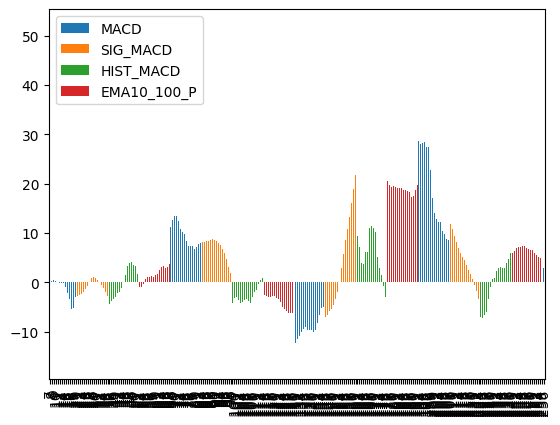

In [24]:
import io
file = io.BytesIO()
r = tmp.plot(kind='bar')
f = r.get_figure()
f.savefig(file,format='png')
file.seek(0)
img_data = file.read()


In [ ]:
plt.figure(figsize=(20,5))
plt.plot(tmp[['MACD','SIG_MACD']],label=["MACD","SIG_MACD"])
plt.plot(tmp[['EMA10_100_P']],'r>',label=[ 'EMA10_100_P'])
# plt.plot(tmp[['HIST_MACD']],)
plt.bar(tmp[['HIST_MACD']].index, tmp['HIST_MACD'], label='HIST')
# plt.bar(tmp[['HIST_MACD']], height=5.0, width=1.5)
# x = tmp[['HIST_MACD']].plot(kind='bar')
plt.legend()
plt.show()
plt.sav

In [ ]:
# s[["close"]]
s[["close","52WH", "52WL", "52WH_P","52WL_P","52WHLP"]].tail()

In [ ]:
(465.3 - 718.2)/(780 - 465.3)

In [ ]:
txt = s[["close","52WH", "52WL", "52WH_P","52WL_P","52WHLP"]].tail().to_html()

In [ ]:
txt

In [ ]:
# email
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage
import os
from base64 import b64encode

me  = 'peri47.study@gmail.com'
recipient = 'rite2babu@gmail.com'
subject = 'email test'

email_server_host = 'smtp.gmail.com'
port = 587
email_username = 'peri47.study@gmail.com'
email_password = 'zjxs btty xvqt gpuj'






msg = MIMEMultipart('alternative')
msg['From'] = me
msg['To'] = recipient
msg['Subject'] = subject
img_format = 'png'


msg.add_header('Content-Type','text/html')
section1 = """\
<html>
    <head> 52WH / L Table here </head>
    <body>
        <section>
            Golden X - nearing stocks: 
            {0}
            Golden X - Signals: 
            {1}
        </section>
        <section>
            52W - H/L - Arranged:
            {2}
        </section>
    </body>
</html>
""".format(s[["close","52WH", "52WL", "52WH_P","52WL_P","52WHLP"]].tail().to_html() )


email_body = body
# msg.a

msg.attach(MIMEText(section1, 'html'))
# msg.attach(MIMEText(section2, ' plain'))
# msg.attach(MIMEText(section3, 'html'))
msgimg = MIMEImage(img_data)
msg.attach(msgimg)

server = smtplib.SMTP(email_server_host, port)
server.ehlo()
server.starttls()
server.login(email_username, email_password)
server.sendmail(me, recipient, msg.as_string())
server.close()

